In [ ]:
# 1. 必要なパッケージのロードとデータの準備
library(tidyverse)
library(tidymodels)
library(liver)
library(gridExtra)
library(grid)
library(DALEX)
library(midr)

# データの読み込みと加工
data(insurance)
df <- insurance %>%
  mutate(gender = as.numeric(gender == "female"),
         smoker = as.numeric(smoker == "yes")) %>%
  select(-region)

# データの分割
set.seed(2023)
split_data <- initial_split(df, prop = 3/4)
train <- training(split_data)
test <- testing(split_data)

# 2. モデルの定義と学習
# 各モデルをリストに格納して一括管理します
models <- list()

# 日本語フォント問題を避けるため、一時的に英語のタイトルに差し替え
model_titles <- c(
  lm = "Linear Regression",
  rf = "Random Forest",
  gbm = "XGBoost",
  nn = "Neural Network",
  tr = "Improved LM"
)

# --- 線形回帰 (lm) ---
models[["lm"]] <- linear_reg() %>% set_engine("lm") %>% 
  fit(charge ~ ., data = train)
models[["lm"]]$title <- "Linear Regression Model"

# --- ランダムフォレスト (rf) ---
models[["rf"]] <- rand_forest(mode = "regression") %>% set_engine("ranger") %>% 
  fit(charge ~ ., data = train)
models[["rf"]]$title <- "Random Forest Model"

# --- XGBoost (gbm) ---
models[["gbm"]] <- boost_tree(mode = "regression") %>% set_engine("xgboost") %>% 
  fit(charge ~ ., data = train)
models[["gbm"]]$title <- "XGBoost Model"

# 3. DALEX説明変数の作成
explainers <- list()
for (name in names(models)) {
  explainers[[name]] <- DALEX::explain(
    model = models[[name]],
    data = select(test, -charge),
    y = test$charge,
    label = models[[name]]$title,
    verbose = FALSE
  )
}


In [4]:
# --- ニューラルネットワーク (nn) の改善版 ---

# A. 標準化のレシピを作成（charge以外の全数値をスケーリング）
nn_recipe <- recipe(charge ~ age + bmi + children + smoker + gender, data = train) %>%
  step_normalize(all_numeric_predictors()) %>%
  prep()

# B. 標準化したデータで学習
# hidden_units（隠れ層のノード数）やepochs（学習回数）を明示的に指定します
models[["nn"]] <- mlp(
  mode = "regression", 
  hidden_units = 5, 
  penalty = 0.01, 
  epochs = 100
) %>% 
  set_engine("nnet", maxit = 500, trace = FALSE) %>% 
  fit(charge ~ ., data = bake(nn_recipe, new_data = train))

models[["nn"]]$title <- "Neural Network Model (Scaled)"

Warning message:
“The argument `maxit` cannot be manually modified and was removed.”


In [5]:
# nn用のexplainerだけ、標準化されたデータ（bakeしたもの）を渡す
explainers[["nn"]] <- DALEX::explain(
  model = models[["nn"]],
  data = bake(nn_recipe, new_data = test) %>% select(-charge),
  y = test$charge,
  label = "Neural Network (Scaled)",
  verbose = FALSE
)


Processing Model: lm 
[OK] DALEX plots calculated
[OK] MID Heatmap generated
[OK] Page generated

Processing Model: rf 
[OK] DALEX plots calculated
[OK] MID Heatmap generated


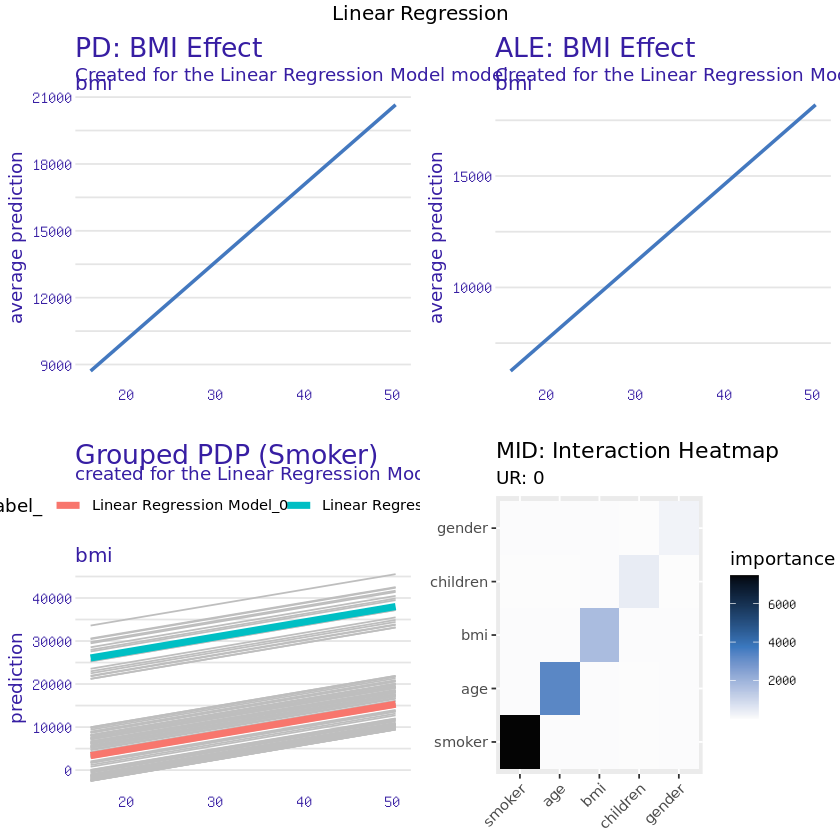

[OK] Page generated

Processing Model: gbm 
[OK] DALEX plots calculated
[OK] MID Heatmap generated


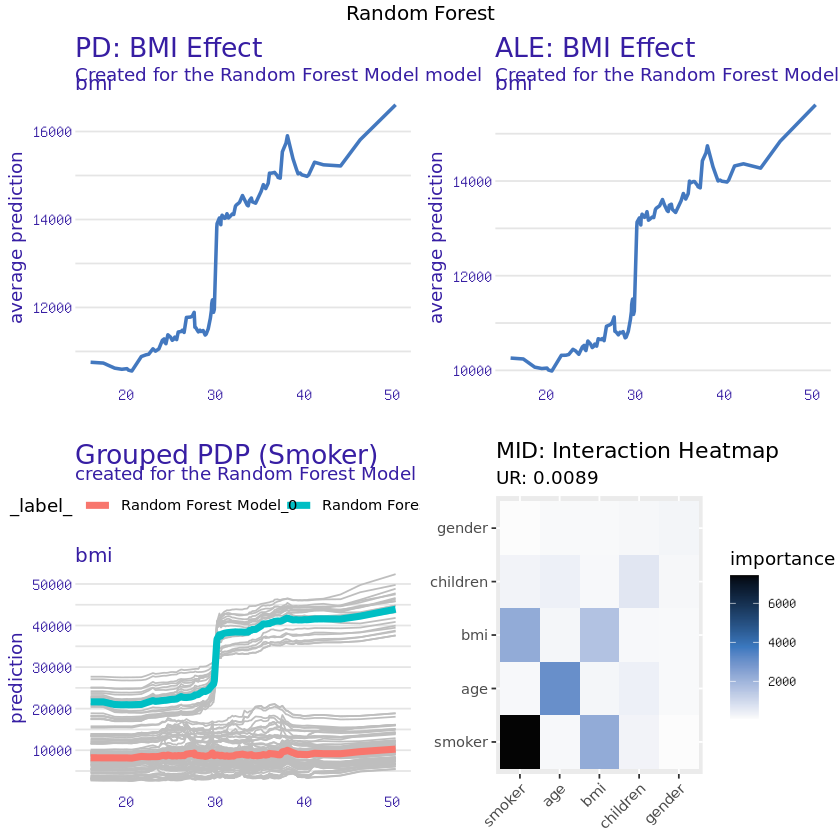

[OK] Page generated

Processing Model: nn 
[OK] DALEX plots calculated
[OK] MID Heatmap generated


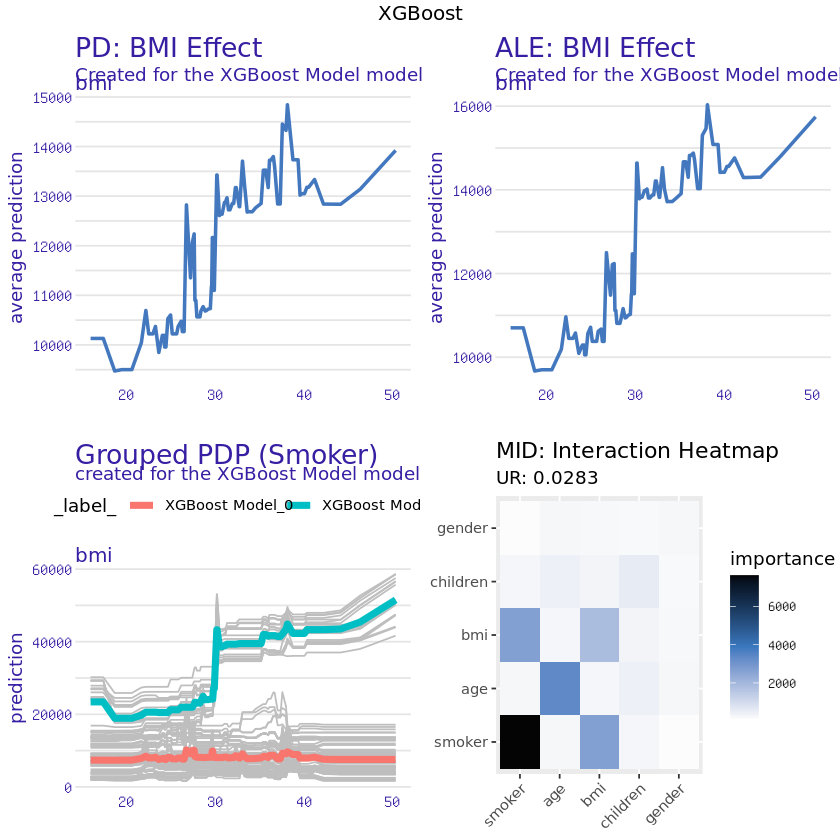

[OK] Page generated


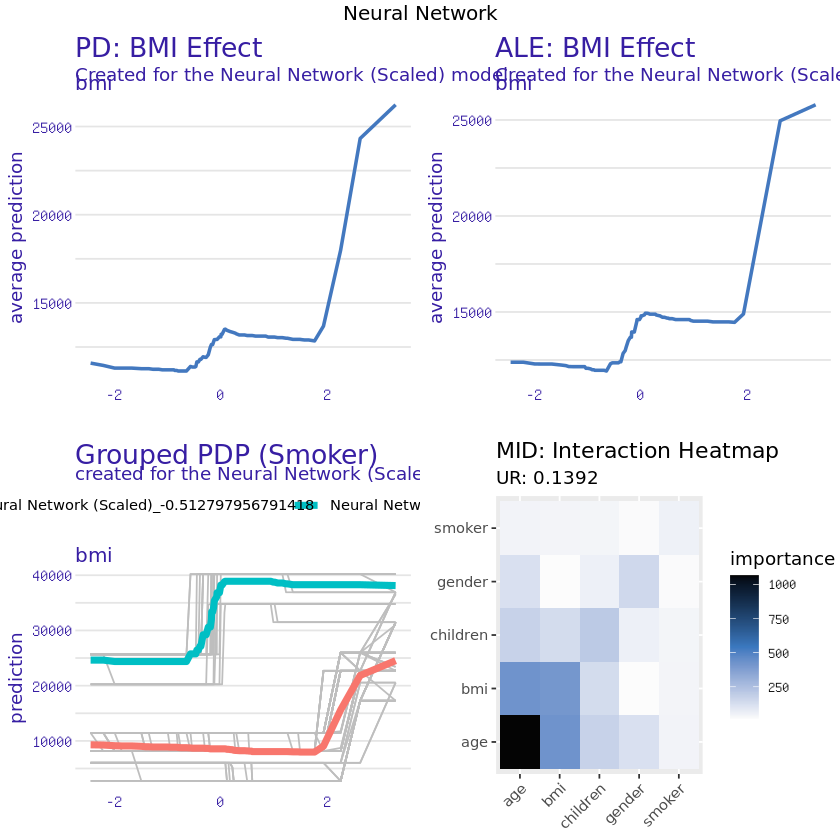

In [11]:


#pdf("Interpretation_Report_English.pdf", width = 14, height = 10)

input_vars <- c("age", "bmi", "children", "smoker", "gender")

for (name in names(models)) {
  if (is.null(models[[name]])) next
  cat("\n============================================\n")
  cat("Processing Model:", name, "\n")
  
  plot_list <- list()
  
  # 1. PD/ALE/Grouped PDP (DALEX)
  tryCatch({
    exp <- explainers[[name]]
    p1_obj <- model_profile(exp, variables = "bmi", type = "partial")
    p2_obj <- model_profile(exp, variables = "bmi", type = "accumulated")
    p3_obj <- model_profile(exp, groups = "smoker", variables = "bmi")
    
    plot_list$p1 <- plot(p1_obj) + ggtitle("PD: BMI Effect")
    plot_list$p2 <- plot(p2_obj) + ggtitle("ALE: BMI Effect")
    plot_list$p3 <- plot(p3_obj, geom = "profiles") + ggtitle("Grouped PDP (Smoker)")
    cat("[OK] DALEX plots calculated\n")
  }, error = function(e) { cat("[FAIL: DALEX]", e$message, "\n") })
  
# 2. MIDヒートマップの計算 
  tryCatch({
    # --- A. 予測データの作成 (5列厳守) ---
    test_df_5cols <- as.data.frame(test[, input_vars])
    y_hat <- predict(models[[name]], new_data = test_df_5cols)$.pred
    
    df_mid <- test_df_5cols
    #df_mid$y <- y_hat
    
    # --- B. 関数分解の実行 ---
    res_mid <- midr::interpret(y ~ (.)^2, data = df_mid, model = models[[name]]$fit)
    
    # --- C. 重要度の抽出とヒートマップ可視化 ---
    # ご提示の例：imp_2d <- mid.importance(mid_2d)
    imp_2d <- mid.importance(res_mid)
    
    # ggmid(imp_2d, type = "heatmap", ...) の形式を使用
    plot_list$p4 <- ggmid(imp_2d, type = "heatmap", theme = "Oslo") +
                    labs(title = "MID: Interaction Heatmap", 
                         subtitle = paste("UR:", round(res_mid$ratio, 4))) +
                    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))
    
    cat("[OK] MID Heatmap generated\n")
  }, error = function(e) { 
    cat("[FAIL: MID]", e$message, "\n") 
  })
  
  # 3. 1ページに出力 (タイトルに日本語を使わない)
  tryCatch({
    active_plots <- plot_list[!sapply(plot_list, is.null)]
    if (length(active_plots) > 0) {
      grid.arrange(grobs = active_plots, ncol = 2, 
                   top = textGrob(model_titles[name], gp = gpar(fontSize = 20)))
      cat("[OK] Page generated\n")
    }
  }, error = function(e) { cat("[FAIL: Output]", e$message, "\n") })
}

#dev.off()
#cat("\nReport saved as 'Interpretation_Report_English.pdf' in:", getwd(), "\n")